# Извлечение графовых признаков из диаграмм
В этом ноутбуке показано, как построить граф из изображения технической схемы, выделить узлы (фигуры и текст),
извлечь для них признаки и получить эмбеддинг графа при помощи графовой нейронной сети.

## Импорт библиотек и определение набора данных
Сначала импортируем необходимые библиотеки и определим класс `Ai2dClipDataset`, который будет использоваться
для чтения изображений и связанных с ними текстов из датасета AI2D.

In [1]:
import json
import random
import hashlib
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

import cv2
import timm
from torchvision import transforms

from sentence_transformers import SentenceTransformer

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATv2Conv, global_mean_pool, GlobalAttention



from pathlib import Path
from typing import Optional, Dict, Tuple
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch_geometric.data import Batch

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
from PIL import Image

import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class Ai2dClipDataset(Dataset):
    """
    Делает пары (изображение, текст) из AI2D:
    text = "Question: ... Correct answer: ..."

    root_dir/
      images/
      questions/
      categories.json (опционально)
    """

    def __init__(self, root_dir: str | Path, text_mode: str = "q+correct") -> None:
        self.root = Path(root_dir)
        self.images_dir = self.root / "images"
        self.questions_dir = self.root / "questions"
        self.text_mode = text_mode

        self.samples: List[Tuple[str, str]] = []  # (image_path, text)

        json_files = sorted(self.questions_dir.glob("*.json"))
        if not json_files:
            raise RuntimeError(f"No question JSONs found in {self.questions_dir}")

        for q_path in json_files:
            with q_path.open("r", encoding="utf-8") as f:
                data = json.load(f)

            image_name = data.get("imageName")
            if not image_name:
                continue

            img_path = self.images_dir / image_name
            if not img_path.exists():
                continue

            questions = data.get("questions", {})
            for q_text, q_data in questions.items():
                answers = q_data.get("answerTexts", [])
                if not answers:
                    continue

                correct_idx = q_data.get("correctAnswer", 0)
                if correct_idx < 0 or correct_idx >= len(answers):
                    correct_idx = 0

                if self.text_mode == "q_only":
                    caption = f"Question: {q_text}"
                elif self.text_mode == "q+options+correct":
                    options_str = "; ".join(
                        f"{chr(ord('A') + i)}. {a}" for i, a in enumerate(answers)
                    )
                    caption = (
                        f"Question: {q_text} "
                        f"Options: {options_str}. "
                        f"Correct answer: {answers[correct_idx]}."
                    )
                else:  # "q+correct"
                    caption = f"Question: {q_text} Correct answer: {answers[correct_idx]}."

                self.samples.append((str(img_path), caption))

        print(f"[AI2D] Loaded {len(self.samples)} (image, text) pairs")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, text = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        return image, text, img_path


def ai2d_collate(batch):
    images, texts, paths = zip(*batch)
    return list(images), list(texts), list(paths)




## Детекция узлов диаграммы
Следующие функции выполняют обнаружение фигур с помощью OpenCV и распознавание текста с использованием pytesseract.
Мы также строим kNN‑граф по центрам прямоугольников.

In [3]:

@dataclass
class Node:
    bbox: Tuple[int, int, int, int]
    kind: str  # "shape" | "text"
    text: str = ""


def bbox_center(b: Tuple[int, int, int, int]) -> Tuple[float, float]:
    x1, y1, x2, y2 = b
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


def detect_shapes_opencv(
    img_bgr: np.ndarray,
    min_area: int = 300,
    max_nodes: int = 80,
) -> List[Tuple[int, int, int, int]]:
    """
    Простая детекция объектов схемы через connected components/contours.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    thr = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV, 31, 7
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thr = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, iterations=1)

    cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        area = w * h
        if area < min_area:
            continue
        boxes.append((x, y, x + w, y + h))

    boxes = sorted(boxes, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]), reverse=True)[:max_nodes]
    return boxes


def detect_text_ocr(
    img_bgr: np.ndarray,
    lang: str = "eng",
    conf_th: int = 60,
) -> List[Node]:
    """
    OCR узлы. Требует pytesseract + установленный tesseract.
    """
    try:
        import pytesseract
    except ImportError as e:
        raise ImportError("Install pytesseract (pip) and tesseract binary.") from e

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    data = pytesseract.image_to_data(rgb, lang=lang, output_type=pytesseract.Output.DICT)

    nodes: List[Node] = []
    n = len(data["text"])
    for i in range(n):
        text = (data["text"][i] or "").strip()
        conf = int(float(data["conf"][i])) if data["conf"][i] != "-1" else -1
        if conf < conf_th or len(text) == 0:
            continue
        x, y, w, h = data["left"][i], data["top"][i], data["width"][i], data["height"][i]
        nodes.append(Node(bbox=(x, y, x + w, y + h), kind="text", text=text))
    return nodes


def build_edges_knn(nodes: List[Node], k: int = 4) -> torch.Tensor:
    """
    Ненаправленный kNN-граф по центрам bbox.
    """
    centers = np.array([bbox_center(n.bbox) for n in nodes], dtype=np.float32)
    if len(centers) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    dists = np.sqrt(((centers[:, None, :] - centers[None, :, :]) ** 2).sum(-1))
    np.fill_diagonal(dists, np.inf)

    edges = []
    for i in range(len(nodes)):
        nn_idx = np.argsort(dists[i])[:k]
        for j in nn_idx:
            edges.append((i, int(j)))
            edges.append((int(j), i))

    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor(edges, dtype=torch.long).t().contiguous()



## Извлечение признаков узлов и построение графа
Класс `NodeFeaturizer` вычисляет эмбеддинги для узлов (визуальные, текстовые, геометрические) и бинарный признак типа узла.
Функция `build_graph` объединяет детекцию, построение рёбер и извлечение признаков, возвращая объект `Data` из PyTorch Geometric.

In [4]:

class NodeFeaturizer:
    """
    Признаки узлов: vision(crop) + text(node_text) + geometry + kind_flag
    """

    def __init__(
        self,
        device: str = "cpu",
        vision_model_name: str = "vit_base_patch16_224",
        text_model_name: str = "sentence-transformers/all-MiniLM-L6-v2",
    ):
        self.device = torch.device(device)
        self.vision_model_name = vision_model_name
        self.text_model_name = text_model_name

        self.vision = timm.create_model(vision_model_name, pretrained=True, num_classes=0)
        self.vision.eval().to(self.device)
        self.vision_dim = self.vision.num_features

        self.text_enc = SentenceTransformer(text_model_name, device=str(self.device))
        self.text_dim = self.text_enc.get_sentence_embedding_dimension()

        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406),
                                 std=(0.229, 0.224, 0.225)),
        ])

    @torch.no_grad()
    def _visual_emb(self, pil_img: Image.Image) -> torch.Tensor:
        x = self.preprocess(pil_img).unsqueeze(0).to(self.device)
        feat = self.vision(x)  # [1, D]
        return feat.squeeze(0).detach().cpu()

    @torch.no_grad()
    def _text_emb(self, text: str) -> torch.Tensor:
        if not text:
            return torch.zeros(self.text_dim, dtype=torch.float32)
        emb = self.text_enc.encode([text], convert_to_tensor=True, normalize_embeddings=False)
        return emb.squeeze(0).detach().cpu()

    def _geom_feat(self, bbox: Tuple[int, int, int, int], W: int, H: int) -> torch.Tensor:
        x1, y1, x2, y2 = bbox
        cx, cy = bbox_center(bbox)
        w = max(1, x2 - x1)
        h = max(1, y2 - y1)
        return torch.tensor([
            cx / W, cy / H,
            w / W, h / H,
            (w * h) / (W * H),
            x1 / W, y1 / H, x2 / W, y2 / H
        ], dtype=torch.float32)

    def extract(self, pil_img: Image.Image, nodes: List[Node]) -> torch.Tensor:
        W, H = pil_img.size
        feats = []
        for n in nodes:
            crop = pil_img.crop((n.bbox[0], n.bbox[1], n.bbox[2], n.bbox[3]))
            v = self._visual_emb(crop)                         # [Dv]
            t = self._text_emb(n.text if n.kind == "text" else "")  # [Dt]
            g = self._geom_feat(n.bbox, W, H)                  # [9]
            kind_flag = torch.tensor([1.0 if n.kind == "text" else 0.0], dtype=torch.float32)  # [1]
            feats.append(torch.cat([v, t, g, kind_flag], dim=0))
        if not feats:
            # fallback 1 node
            return torch.zeros((1, self.vision_dim + self.text_dim + 9 + 1), dtype=torch.float32)
        return torch.stack(feats, dim=0)


def build_graph(
    image_path: str,
    featurizer: NodeFeaturizer,
    ocr_lang: str = "eng",
    min_area: int = 300,
    max_nodes: int = 80,
    ocr_conf: int = 60,
    knn_k: int = 4,
) -> Data:
    """Extract a graph (nodes + edges + cached node features) from a diagram image."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise RuntimeError(f"cv2.imread failed: {image_path}")

    pil_img = Image.open(image_path).convert("RGB")

    shapes = detect_shapes_opencv(img_bgr, min_area=min_area, max_nodes=max_nodes)
    shape_nodes = [Node(bbox=b, kind="shape") for b in shapes]
    text_nodes = detect_text_ocr(img_bgr, lang=ocr_lang, conf_th=ocr_conf)

    nodes = shape_nodes + text_nodes
    edge_index = build_edges_knn(nodes, k=knn_k)
    x = featurizer.extract(pil_img, nodes)  # (N, D)

    return Data(x=x, edge_index=edge_index)

## Графовая модель для диаграмм
Класс `GraphEncoder` принимает изображение и список узлов и использует графовые сверточные слои GATv2 для агрегации признаков.
После двух слоёв и глобального внимания получается эмбеддинг всей диаграммы, который можно использовать в задачах классификации или поиска.

In [5]:
class GraphEncoder(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int = 256,
        out_dim: int = 256,
        num_heads: int = 4,
        use_attn_pool: bool = True,
    ):
        super().__init__()
        self.proj = nn.Linear(in_dim, hidden_dim)

        # Attention message passing
        self.gnn1 = GATv2Conv(hidden_dim, hidden_dim // num_heads, heads=num_heads, dropout=0.1)
        self.gnn2 = GATv2Conv(hidden_dim, hidden_dim // num_heads, heads=num_heads, dropout=0.1)

        self.out = nn.Linear(hidden_dim, out_dim)

        self.use_attn_pool = use_attn_pool
        
        gate_hidden = max(1, out_dim // 2)
        gate_nn = nn.Sequential(
            nn.Linear(out_dim, gate_hidden),
            nn.GELU(),
            nn.Linear(gate_hidden, 1),
        )
        self.pool = GlobalAttention(gate_nn=gate_nn)


    def forward(self, batch: Batch) -> torch.Tensor:
        x, edge_index, batch_idx = batch.x, batch.edge_index, batch.batch

        x = F.gelu(self.proj(x))
        x = F.gelu(self.gnn1(x, edge_index))
        x = F.gelu(self.gnn2(x, edge_index))
        x = F.gelu(self.out(x))

        if self.pool is not None:
            graph_emb = self.pool(x, batch_idx)
        else:
            graph_emb = global_mean_pool(x, batch_idx)

        return graph_emb


- **FeatureCache** — кэш на диск + в память для ускорения:
  - кэширует **графы** по изображениям (PyG `Data`) и **эмбеддинги текстов**
  - ключ учитывает путь, время изменения файла и параметры извлечения + `signature`
  - хранит в `<cache_dir>/<signature>/graphs` и `<cache_dir>/<signature>/texts`

- **contrastive_loss** — контрастивный loss для “картинка↔текст”:
  - строит матрицу похожести `z_img @ z_txt.T / temperature`
  - обучает так, чтобы правильная пара была “самой близкой” (диагональ)

- **evaluate_retrieval** — оценка retrieval на val:
  - для каждого батча строит графы (с кэшем или без)
  - получает текстовые эмбеддинги (с кэшем или без)
  - прогоняет через `gnn` и `text_proj`, нормализует
  - считает similarity-матрицу и **Recall@K** для:
    - image→text
    - text→image
    - среднее по двум направлениям


In [6]:
class FeatureCache:

    def __init__(self, cache_dir: str | Path, signature: str, enabled: bool = True) -> None:
        self.enabled = enabled
        self.signature = str(signature)

        self.root = Path(cache_dir)
        self.graph_dir = self.root / self.signature / "graphs"
        self.text_dir = self.root / self.signature / "texts"
        self.graph_dir.mkdir(parents=True, exist_ok=True)
        self.text_dir.mkdir(parents=True, exist_ok=True)

        self._mem_graph: Dict[str, Data] = {}
        self._mem_text: Dict[str, torch.Tensor] = {}

    @staticmethod
    def _sha1(s: str) -> str:
        return hashlib.sha1(s.encode("utf-8")).hexdigest()

    @staticmethod
    def make_signature(
        vision_model_name: str,
        text_model_name: str,
        ocr_lang: str,
        min_area: int,
        max_nodes: int,
        ocr_conf: int,
        knn_k: int,
    ) -> str:
        payload = {
            "vision_model_name": vision_model_name,
            "text_model_name": text_model_name,
            "ocr_lang": ocr_lang,
            "min_area": int(min_area),
            "max_nodes": int(max_nodes),
            "ocr_conf": int(ocr_conf),
            "knn_k": int(knn_k),
            "cache_version": 1,
        }
        raw = json.dumps(payload, sort_keys=True, ensure_ascii=False)
        return hashlib.sha1(raw.encode("utf-8")).hexdigest()[:16]

    def get_graph(
        self,
        image_path: str,
        featurizer: NodeFeaturizer,
        ocr_lang: str = "eng",
        min_area: int = 300,
        max_nodes: int = 80,
        ocr_conf: int = 60,
        knn_k: int = 4,
    ) -> Data:
        if not self.enabled:
            return build_graph(
                image_path=image_path,
                featurizer=featurizer,
                ocr_lang=ocr_lang,
                min_area=min_area,
                max_nodes=max_nodes,
                ocr_conf=ocr_conf,
                knn_k=knn_k,
            )

        p = Path(image_path)
        try:
            mtime = p.stat().st_mtime_ns
            resolved = str(p.resolve())
        except FileNotFoundError:
            mtime = 0
            resolved = str(p)

        key = self._sha1(
            f"{resolved}|{mtime}|{ocr_lang}|{min_area}|{max_nodes}|{ocr_conf}|{knn_k}|{self.signature}"
        )

        if key in self._mem_graph:
            return self._mem_graph[key]

        fpath = self.graph_dir / f"{key}.pt"
        if fpath.exists():
            import inspect
            if "weights_only" in inspect.signature(torch.load).parameters:
                g = torch.load(fpath, map_location="cpu", weights_only=False)
            else:
                g = torch.load(fpath, map_location="cpu")
        else:
            g = build_graph(
                image_path=image_path,
                featurizer=featurizer,
                ocr_lang=ocr_lang,
                min_area=min_area,
                max_nodes=max_nodes,
                ocr_conf=ocr_conf,
                knn_k=knn_k,
            )
            torch.save(g, fpath)

        self._mem_graph[key] = g
        return g

    def get_text_batch(
        self,
        texts: List[str],
        text_encoder,
        normalize: bool = False,
    ) -> torch.Tensor:

        if not self.enabled:
            with torch.no_grad():
                embs = text_encoder.encode(
                    texts,
                    convert_to_tensor=True,
                    normalize_embeddings=normalize,
                )
            if isinstance(embs, torch.Tensor):
                return embs.detach().cpu()
            return torch.tensor(embs, dtype=torch.float32)

        order_keys: List[str] = []
        missing_texts: List[str] = []
        missing_keys: List[str] = []

        for t in texts:
            t = t or ""
            key = self._sha1(f"{t}|{self.signature}")
            order_keys.append(key)

            if key in self._mem_text:
                continue

            fpath = self.text_dir / f"{key}.pt"
            if fpath.exists():
                import inspect
                if "weights_only" in inspect.signature(torch.load).parameters:
                    self._mem_text[key] = torch.load(fpath, map_location="cpu", weights_only=False)
                else:
                    self._mem_text[key] = torch.load(fpath, map_location="cpu")
            else:
                missing_texts.append(t)
                missing_keys.append(key)

        if missing_texts:
            with torch.no_grad():
                embs = text_encoder.encode(
                    missing_texts,
                    convert_to_tensor=True,
                    normalize_embeddings=normalize,
                )
            if isinstance(embs, torch.Tensor):
                embs = embs.detach().cpu()
            else:
                # sentence-transformers sometimes returns numpy
                embs = torch.tensor(embs, dtype=torch.float32)

            for k, e in zip(missing_keys, embs):
                e = e.contiguous()
                self._mem_text[k] = e
                torch.save(e, self.text_dir / f"{k}.pt")

        return torch.stack([self._mem_text[k] for k in order_keys], dim=0)





def contrastive_loss(z_img: torch.Tensor, z_txt: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    logits = (z_img @ z_txt.t()) / temperature
    labels = torch.arange(logits.size(0), device=logits.device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.t(), labels)
    return (loss_i2t + loss_t2i) / 2.0
    
@torch.no_grad()
def recall_at_k_from_sim(sim: torch.Tensor, ks=(1, 5, 10)) -> Dict[int, float]:
    """
    sim: [N, N] similarity, где правильная пара соответствует диагонали (i ↔ i).
    Возвращает Recall@K в долях (0..1).
    """
    ranks = sim.argsort(dim=1, descending=True)              
    gt = torch.arange(sim.size(0), device=sim.device).unsqueeze(1)  

    out = {}
    for k in ks:
        hit = (ranks[:, :k] == gt).any(dim=1).float().mean().item()
        out[k] = hit
    return out


@torch.no_grad()
def evaluate_retrieval(
    gnn: GraphEncoder,
    text_proj: nn.Module,
    featurizer: NodeFeaturizer,
    val_loader: DataLoader,
    device: torch.device,
    ks=(1, 5, 10),
    max_items: Optional[int] = None,
    cache: Optional[FeatureCache] = None,
    ocr_lang: str = "eng",
    min_area: int = 300,
    max_nodes: int = 80,
    ocr_conf: int = 60,
    knn_k: int = 4,
):
    gnn.eval()
    text_proj.eval()

    img_embs = []
    txt_embs = []
    seen = 0

   
    for images, texts, paths in val_loader:

        # 1) графы по картинкам (с кэшем)
        if cache is None:
            graphs = [
                build_graph(
                    p,
                    featurizer,
                    ocr_lang=ocr_lang,
                    min_area=min_area,
                    max_nodes=max_nodes,
                    ocr_conf=ocr_conf,
                    knn_k=knn_k,
                )
                for p in paths
            ]
        else:
            graphs = [
                cache.get_graph(
                    p,
                    featurizer,
                    ocr_lang=ocr_lang,
                    min_area=min_area,
                    max_nodes=max_nodes,
                    ocr_conf=ocr_conf,
                    knn_k=knn_k,
                )
                for p in paths
            ]

        batch_graph = Batch.from_data_list(graphs).to(device)

        # 2) текстовые эмбеддинги (с кэшем)
        if cache is None:
            text_emb = featurizer.text_enc.encode(
                list(texts),
                convert_to_tensor=True,
                normalize_embeddings=False
            ).to(device)
        else:
            text_emb = cache.get_text_batch(list(texts), featurizer.text_enc, normalize=False).to(device)

        # 3) эмбеддинги и нормализация
        z_img = F.normalize(gnn(batch_graph), dim=1)
        z_txt = F.normalize(text_proj(text_emb), dim=1)

        img_embs.append(z_img.detach().cpu())
        txt_embs.append(z_txt.detach().cpu())

        seen += len(texts)
        if max_items is not None and seen >= max_items:
            break

    img_embs = torch.cat(img_embs, dim=0)
    txt_embs = torch.cat(txt_embs, dim=0)
    sim = img_embs @ txt_embs.t()

    r_i2t = recall_at_k_from_sim(sim, ks=ks)
    r_t2i = recall_at_k_from_sim(sim.t(), ks=ks)
    r_mean = {k: 0.5 * (r_i2t[k] + r_t2i[k]) for k in ks}
    return r_i2t, r_t2i, r_mean



Функция делает извлечения признаков из изображения:

- Загружает изображение (OpenCV + PIL), получает размеры `H, W`.
- Находит **фигуры** (bbox) через `detect_shapes_opencv(...)` и превращает их в `Node(kind="shape")`.
- Находит **текстовые области** через OCR `detect_text_ocr(...)` (с порогом `ocr_conf`).
- Объединяет все узлы и строит связи **kNN-графом**: `build_edges_knn(nodes, k=4)`.
- Считает матрицу признаков узлов: `x = featurizer.extract(pil_img, nodes)` → размер `(N_nodes, D_feat)`.
- Печатает статистику: сколько узлов, сколько рёбер, форма `x`, первые OCR-тексты.
- Рисует картинку с рамками:
  - **красные** — найденные фигуры
  - **зелёные** — текстовые OCR-боксы


In [7]:


def visualize_extraction(
    image_path: str,
    caption: str,
    featurizer: NodeFeaturizer,
    ocr_lang: str = "eng",
    max_nodes_show: int = 30,
    ocr_conf: int = 60,
):
    img_bgr = cv2.imread(image_path)
   
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.open(image_path).convert("RGB")

    H, W = img_rgb.shape[:2]

    shape_boxes = detect_shapes_opencv(img_bgr, min_area=300, max_nodes=max_nodes_show)
    shape_nodes = [Node(bbox=b, kind="shape") for b in shape_boxes]

    text_nodes = detect_text_ocr(img_bgr, lang=ocr_lang, conf_th=ocr_conf)


    nodes = shape_nodes + text_nodes
    edge_index = build_edges_knn(nodes, k=4)

    x = featurizer.extract(pil_img, nodes)

    print("IMAGE:", image_path)
    print("TEXT (caption):", caption[:200], "..." if len(caption) > 200 else "")
    print(f"Detected shapes: {len(shape_nodes)}")
    print(f"Detected OCR text nodes: {len(text_nodes)}")
    print("Graph edges:", edge_index.size(1))
    print("Node feature matrix x:", tuple(x.shape), "(N_nodes, D_feat)")

    if text_nodes:
        print("\nOCR texts (first 20):")
        for i, n in enumerate(text_nodes[:20]):
            print(f"  {i+1:02d}. '{n.text}' bbox={n.bbox}")

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(img_rgb)
    ax.set_title("Original image + detected nodes (red=shapes, green=text)")
    ax.axis("off")

    for b in shape_boxes:
        x1, y1, x2, y2 = b
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1.5, edgecolor="red"))

    for n in text_nodes:
        x1, y1, x2, y2 = n.bbox
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1.5, edgecolor="lime"))

    plt.show()


[AI2D] Loaded 15501 (image, text) pairs
IMAGE: ai2d\images\1010.png
TEXT (caption): Question: In this diagram, which leaf pattern represents the Umbel pattern? Correct answer: P. 
Detected shapes: 25
Detected OCR text nodes: 18
Graph edges: 344
Node feature matrix x: (43, 1162) (N_nodes, D_feat)

OCR texts (first 20):
  01. '‘Opposite' bbox=(86, 67, 143, 81)
  02. 'leaves' bbox=(87, 85, 128, 96)
  03. 'Umbel' bbox=(53, 241, 93, 269)
  04. 'Spike' bbox=(215, 248, 250, 261)
  05. 'anther' bbox=(37, 370, 78, 380)
  06. 'filament' bbox=(43, 390, 94, 402)
  07. 'receptacle' bbox=(7, 418, 73, 432)
  08. 'flower' bbox=(34, 444, 73, 454)
  09. 'stalk' bbox=(77, 444, 106, 454)
  10. '—' bbox=(112, 450, 119, 452)
  11. 'Superior' bbox=(102, 479, 161, 493)
  12. 'ovary' bbox=(166, 481, 203, 492)
  13. 'leaves' bbox=(397, 85, 438, 96)
  14. 'Raceme' bbox=(364, 248, 417, 259)
  15. 'ovary' bbox=(306, 428, 341, 440)
  16. 'receptacle' bbox=(295, 447, 361, 460)
  17. 'Inferior' bbox=(334, 478, 383, 4

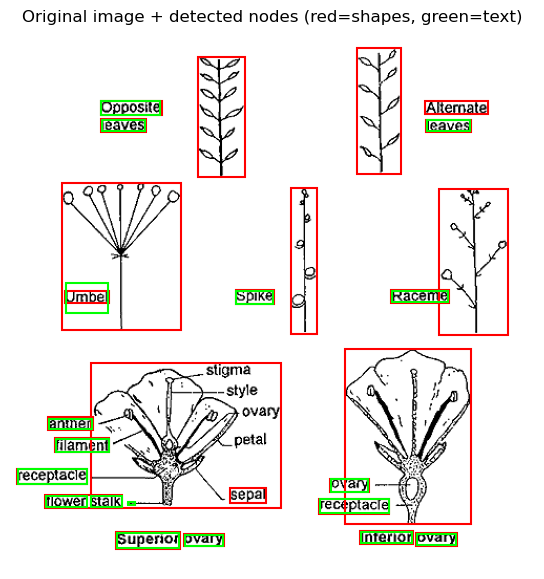

In [8]:
data_root = Path("ai2d")
ds = Ai2dClipDataset(data_root, text_mode="q+correct")

device = "cuda" 
featurizer = NodeFeaturizer(device=device) 
img, caption, img_path = ds[34]
visualize_extraction(img_path, caption, featurizer, ocr_lang="eng")


## _demo_extraction (qualitative inspection)

Функция выполняет качественную валидацию пайплайна извлечения признаков для одного примера: детектирует графовые узлы (геометрические элементы и текстовые регионы OCR), строит kNN-связи, извлекает векторные признаки узлов и визуализирует наложение bbox. Дополнительно выводит базовые статистики графа (|V|, |E|) и размерность матрицы признаков X.

---

## train (contrastive retrieval training)

Процедура обучает двухмодальную retrieval-модель «диаграмма ↔ текст» в CLIP-постановке. Для изображений строится граф представления (узлы: shape/OCR; рёбра: kNN), далее граф кодируется `GraphEncoder` в эмбеддинг z_img. Текст кодируется энкодером и проецируется `text_proj` в совместное пространство z_txt. Обучение выполняется симметричной контрастивной функцией потерь (image→text и text→image) с температурой. Для ускорения используется дисково-памятный кэш графов и текстовых эмбеддингов. После каждой эпохи качество оценивается метриками Recall@K для обоих направлений (I2T, T2I) и их средним.


In [9]:


def _demo_extraction(
    image_path: str,
    caption: str,
    featurizer,
    ocr_lang: str = "eng",
    ocr_conf: int = 60,
    max_nodes_show: int = 30,
):
    """
    Печатает и рисует пример:
    - оригинал
    - боксы shapes (red)
    - боксы OCR-текста (lime)
    - краткие статистики графа и фичей
    """
    img_bgr = cv2.imread(image_path)
  

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.open(image_path).convert("RGB")

    # shapes
    shape_boxes = detect_shapes_opencv(img_bgr, min_area=300, max_nodes=max_nodes_show)
    shape_nodes = [Node(bbox=b, kind="shape") for b in shape_boxes]

    # OCR
    text_nodes = detect_text_ocr(img_bgr, lang=ocr_lang, conf_th=ocr_conf)


    nodes = shape_nodes + text_nodes
    edge_index = build_edges_knn(nodes, k=4)

    x = featurizer.extract(pil_img, nodes)

    print("\n" + "=" * 80)
    print("DEMO SAMPLE")
    print("IMAGE:", image_path)
    print("CAPTION:", caption)
    print(f"Shapes detected: {len(shape_nodes)}")
    print(f"OCR nodes detected: {len(text_nodes)}")
    print(f"Edges: {edge_index.size(1)}")
    print(f"Node features x: {tuple(x.shape)}  (N_nodes, D_feat)")
    if text_nodes:
        print("\nOCR texts (first 20):")
        for i, n in enumerate(text_nodes[:20]):
            print(f"  {i+1:02d}. '{n.text}' bbox={n.bbox}")
    print("=" * 80 + "\n")

    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    ax.imshow(img_rgb)
    ax.set_title("Original + detected nodes (red=shapes, green=text)")
    ax.axis("off")

    for (x1, y1, x2, y2) in shape_boxes:
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1.5, edgecolor="red"))

    for n in text_nodes:
        x1, y1, x2, y2 = n.bbox
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1.5, edgecolor="lime"))

    plt.show()


def train(
    
    data_root: str | Path,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    batch_size: int = 4,
    epochs: int = 5,
    lr: float = 2e-4,
    hidden_dim: int = 256,
    out_dim: int = 256,
    temperature: float = 0.07,
    text_mode: str = "q+correct",
    ocr_lang: str = "eng",
    show_demo: bool = True,          
    demo_max_nodes: int = 30,         
    demo_ocr_conf: int = 60,           
    eval_max_items: int = None,
    use_cache: bool = True,
    cache_dir: Optional[str | Path] = None,
    extract_min_area: int = 300,
    extract_max_nodes: int = 80,
    extract_ocr_conf: int = 60,
    extract_knn_k: int = 4,
    use_attn_pool: bool = True,
):
    """
    Обучение retrieval-модели:
    - графовая энкодер-сеть по диаграмме
    - текстовый проектор
    - contrastive loss (CLIP-style)
    + tqdm прогресс-бар и demo извлечения на первом батче
    """
    
    device = torch.device(device)
    data_root = Path(data_root)

    # dataset
    dataset = Ai2dClipDataset(data_root, text_mode=text_mode)

    # split
    n = len(dataset)
    n_train = int(0.9 * n)
    n_val = n - n_train
    g = torch.Generator().manual_seed(42)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=g)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=ai2d_collate)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=ai2d_collate)

    featurizer = NodeFeaturizer(device=str(device))

    if cache_dir is None:
        cache_dir = data_root / "_cache_features"

    cache_sig = FeatureCache.make_signature(
        vision_model_name=featurizer.vision_model_name,
        text_model_name=featurizer.text_model_name,
        ocr_lang=ocr_lang,
        min_area=extract_min_area,
        max_nodes=extract_max_nodes,
        ocr_conf=extract_ocr_conf,
        knn_k=extract_knn_k,
    )
    cache = FeatureCache(cache_dir=cache_dir, signature=cache_sig, enabled=use_cache)

    in_dim = featurizer.vision_dim + featurizer.text_dim + 9 + 1

    gnn = GraphEncoder(in_dim=in_dim, hidden_dim=hidden_dim, out_dim=out_dim, use_attn_pool=use_attn_pool).to(device)
    text_proj = nn.Sequential(
        nn.Linear(featurizer.text_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, out_dim),
    ).to(device)

    optimizer = torch.optim.AdamW(list(gnn.parameters()) + list(text_proj.parameters()), lr=lr)

    demo_done = False

    for epoch in range(1, epochs + 1):
        gnn.train()
        text_proj.train()

        epoch_loss = 0.0
        n_steps = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", total=len(train_loader))

        for images, texts, paths in pbar:

            if show_demo and (not demo_done):
                _demo_extraction(
                    image_path=paths[0],
                    caption=texts[0],
                    featurizer=featurizer,
                    ocr_lang=ocr_lang,
                    ocr_conf=demo_ocr_conf,
                    max_nodes_show=demo_max_nodes,
                )
                demo_done = True

            t0 = time.time()

            graphs = [cache.get_graph(p, featurizer, ocr_lang=ocr_lang, min_area=extract_min_area, max_nodes=extract_max_nodes, ocr_conf=extract_ocr_conf, knn_k=extract_knn_k) for p in paths]
            batch_graph = Batch.from_data_list(graphs).to(device)

            text_emb = cache.get_text_batch(list(texts), featurizer.text_enc, normalize=False).to(device).clone().detach()

            t_prep = time.time() - t0

            t1 = time.time()

            z_img = gnn(batch_graph)
            z_txt = text_proj(text_emb)

            z_img = F.normalize(z_img, dim=1)
            z_txt = F.normalize(z_txt, dim=1)

            loss = contrastive_loss(z_img, z_txt, temperature=temperature)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            t_train = time.time() - t1

            epoch_loss += float(loss.item())
            n_steps += 1

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "prep_s": f"{t_prep:.2f}",
                "train_s": f"{t_train:.2f}",
            })

        avg_loss = epoch_loss / max(1, n_steps)

        r_i2t, r_t2i, r_mean = evaluate_retrieval(
            gnn=gnn,
            text_proj=text_proj,
            featurizer=featurizer,
            val_loader=val_loader,
            device=device,
            ks=(1, 5, 10),
            cache=cache,
            ocr_lang=ocr_lang,
            min_area=extract_min_area,
            max_nodes=extract_max_nodes,
            ocr_conf=extract_ocr_conf,
            knn_k=extract_knn_k,
            max_items=eval_max_items,
        )
        
        print(
            f"Epoch {epoch}/{epochs} finished | "
            f"loss={avg_loss:.4f} | "
            f"I2T: R@1={r_i2t[1]:.4f} R@5={r_i2t[5]:.4f} R@10={r_i2t[10]:.4f} | "
            f"T2I: R@1={r_t2i[1]:.4f} R@5={r_t2i[5]:.4f} R@10={r_t2i[10]:.4f} | "
            f"MEAN: R@1={r_mean[1]:.4f} R@5={r_mean[5]:.4f} R@10={r_mean[10]:.4f}"
        )


    return gnn, text_proj, featurizer


[AI2D] Loaded 15501 (image, text) pairs


C:\Users\Jet\AppData\Local\Temp\ipykernel_18528\340873110.py:506: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate_nn)


Epoch 1/50:   0%|          | 0/1744 [00:00<?, ?it/s]


DEMO SAMPLE
IMAGE: ai2d\images\344.png
CAPTION: Question: What are some ways in which a grasshopper's life cycle differs from that of a mealworm beetle's? Correct answer: The mealworm beetle goes through an additional step..
Shapes detected: 16
OCR nodes detected: 3
Edges: 152
Node features x: (19, 1162)  (N_nodes, D_feat)

OCR texts (first 20):
  01. 'Grasshopper' bbox=(70, 212, 179, 229)
  02. 'Mealworm' bbox=(355, 213, 440, 226)
  03. 'Beetle' bbox=(446, 213, 500, 226)



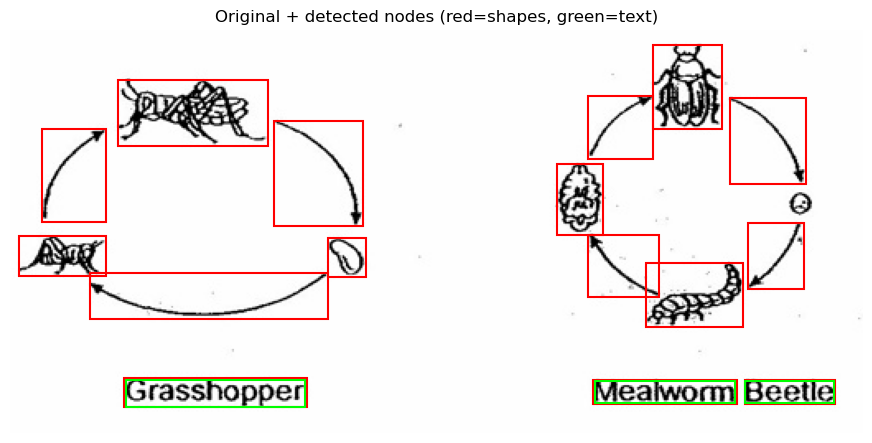

Epoch 1/50 finished | loss=1.1755 | I2T: R@1=0.0800 R@5=0.2950 R@10=0.4550 | T2I: R@1=0.0600 R@5=0.2600 R@10=0.4650 | MEAN: R@1=0.0700 R@5=0.2775 R@10=0.4600


Epoch 2/50:   0%|          | 0/1744 [00:00<?, ?it/s]

Epoch 2/50 finished | loss=0.7393 | I2T: R@1=0.0950 R@5=0.4100 R@10=0.5450 | T2I: R@1=0.0650 R@5=0.3600 R@10=0.5450 | MEAN: R@1=0.0800 R@5=0.3850 R@10=0.5450


Epoch 3/50:   0%|          | 0/1744 [00:00<?, ?it/s]

Epoch 3/50 finished | loss=0.5921 | I2T: R@1=0.1300 R@5=0.4000 R@10=0.6050 | T2I: R@1=0.1300 R@5=0.4300 R@10=0.5800 | MEAN: R@1=0.1300 R@5=0.4150 R@10=0.5925


...

Epoch 48/50 finished | loss=0.0719 | I2T: R@1=0.2550 R@5=0.5900 R@10=0.7650 | T2I: R@1=0.2350 R@5=0.6000 R@10=0.7600 | MEAN: R@1=0.2450 R@5=0.5950 R@10=0.7625


Epoch 49/50:   0%|          | 0/1744 [00:00<?, ?it/s]

Epoch 49/50 finished | loss=0.0712 | I2T: R@1=0.2900 R@5=0.6300 R@10=0.7650 | T2I: R@1=0.2850 R@5=0.6150 R@10=0.7650 | MEAN: R@1=0.2875 R@5=0.6225 R@10=0.7650


Epoch 50/50:   0%|          | 0/1744 [00:00<?, ?it/s]

Epoch 50/50 finished | loss=0.0701 | I2T: R@1=0.3000 R@5=0.5950 R@10=0.7650 | T2I: R@1=0.2350 R@5=0.5850 R@10=0.7650 | MEAN: R@1=0.2675 R@5=0.5900 R@10=0.7650


In [10]:
data_root = Path("ai2d")
gnn, text_proj, featurizer = train(
    data_root=data_root,
    batch_size=8,
    epochs=50,
    show_demo=True,       
    eval_max_items=None,  
)
